In [17]:
# Cellule 1 : Imports
from pathlib import Path
import sys

# --- Importation de nos modules ---
PROJECT_FCT = Path("../maladiescardiaques").resolve()
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_FCT))

print(f"Racine du projet ajoutée au PATH: {PROJECT_FCT}")

try:
    # Importer les fonctions depuis vos fichiers .py
    from traitementDonnées import load_and_split_data
    
    # Importer TOUTES les fonctions nécessaires depuis le module de plotting
    from PlotTrainingFonct import (
        EntrainementModele, 
        CalculPerf, 
        MatriceConfusion, 
        PlotProbabilites, 
        CourbeROC, 
        PlotFrontiereDecision
    )

    print("Modules 'traitementDonnées', 'training' et 'PlotTrainingFonct' importés avec succès.")
    
except ImportError as e:
    print(f"ERREUR D'IMPORTATION : {e}")
    print("Veuillez vérifier les noms de vos fichiers dans le dossier 'maladiescardiaques/'.")

Racine du projet ajoutée au PATH: C:\Users\sebdr\OneDrive\Bureau\sherbrooke\IFT 603 - Techniques d'apprentissages\ProjetSession\maladiescardiaques\maladiescardiaques
Modules 'traitementDonnées', 'training' et 'PlotTrainingFonct' importés avec succès.


In [18]:
# Cellule 2: Chargement des données
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cardiaque.csv"
print(f"Chargement des données depuis: {DATA_PATH}")

data = load_and_split_data(DATA_PATH)
X_train, X_test, y_train, y_test = data

print("Données chargées et divisées.")

Chargement des données depuis: C:\Users\sebdr\OneDrive\Bureau\sherbrooke\IFT 603 - Techniques d'apprentissages\ProjetSession\maladiescardiaques\data\raw\cardiaque.csv
Variable cible 'num' encodée. Valeurs uniques : [0 1]
Données chargées. Entraînement : (242, 13), Test : (61, 13)
Données chargées et divisées.


In [19]:
# Cellule 3: Entraînement d'un seul modèle (KNeighbors)
results = EntrainementModele(X_train, y_train, 1)

Début de l'entraînement d'un seul modèle : KNeighbors...
------------------------------------------------------------
🔄 Optimisation de : KNeighbors...
✅ Terminé : KNeighbors (Score CV F1: 0.8014) [Durée: 0.37s]
------------------------------------------------------------
Entraînement complet terminé en 0.37 secondes.


In [20]:
# Cellule 4: Calcul des performances finales sur le Test Set
results = CalculPerf(results, X_test, y_test)

Calcul des performances finales sur l'ensemble de Test...
Scores finaux calculés.



--- Visualisation 1 : Matrice de Confusion ---

--- Analyse détaillée du meilleur modèle : KNeighbors ---

Rapport de Classification (Test Set):
                precision    recall  f1-score   support

No Disease (0)       0.94      0.88      0.91        33
   Disease (1)       0.87      0.93      0.90        28

      accuracy                           0.90        61
     macro avg       0.90      0.90      0.90        61
  weighted avg       0.90      0.90      0.90        61



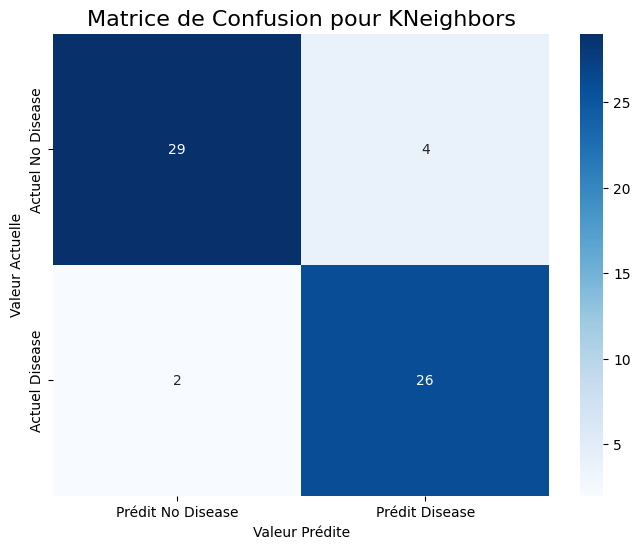

In [21]:
# Cellule 5: GRAPHIQUE 1 - Matrice de Confusion
MatriceConfusion(results, y_test)


--- Visualisation 2 : Probabilités (Test Set) ---


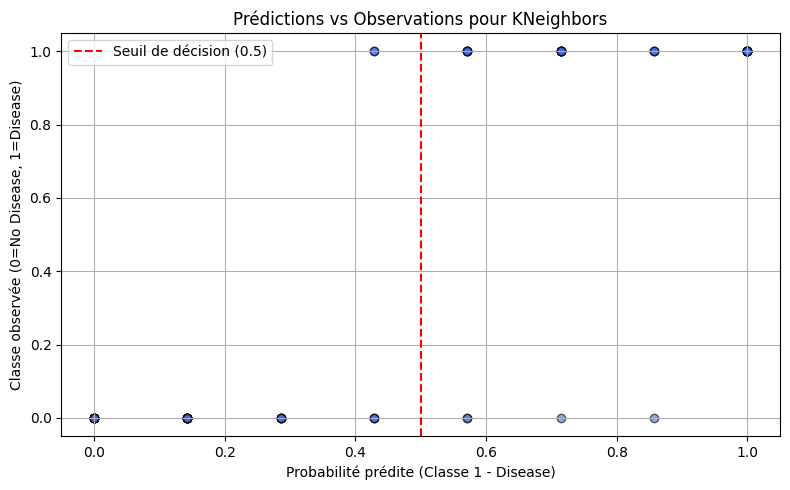

In [22]:
# Cellule 6: GRAPHIQUE 2 - Probabilités Prédites vs Observations
PlotProbabilites(results, y_test)


--- Visualisation 3 : Courbe ROC (Test Set) ---


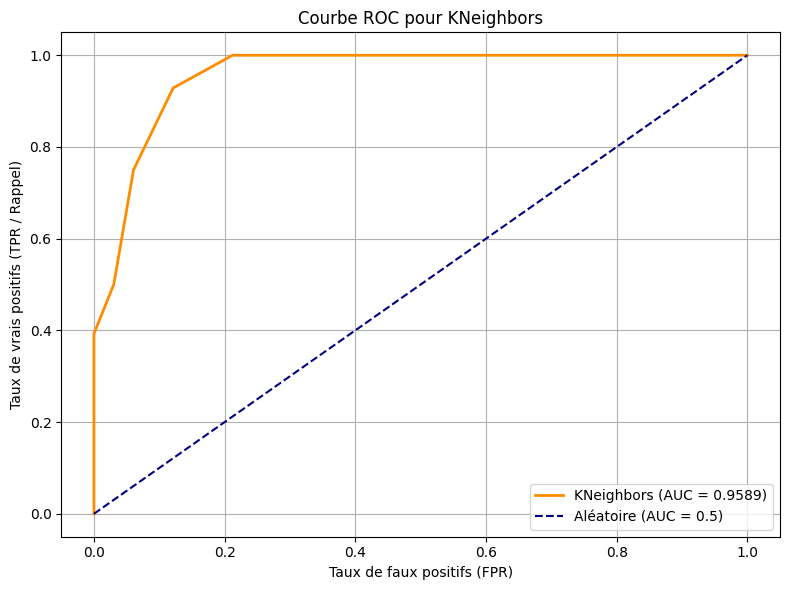

In [23]:
# Cellule 7: GRAPHIQUE 3 - Courbe ROC
CourbeROC(results, y_test)


--- Visualisation 4 : Frontière de Décision (sur données d'entraînement) ---


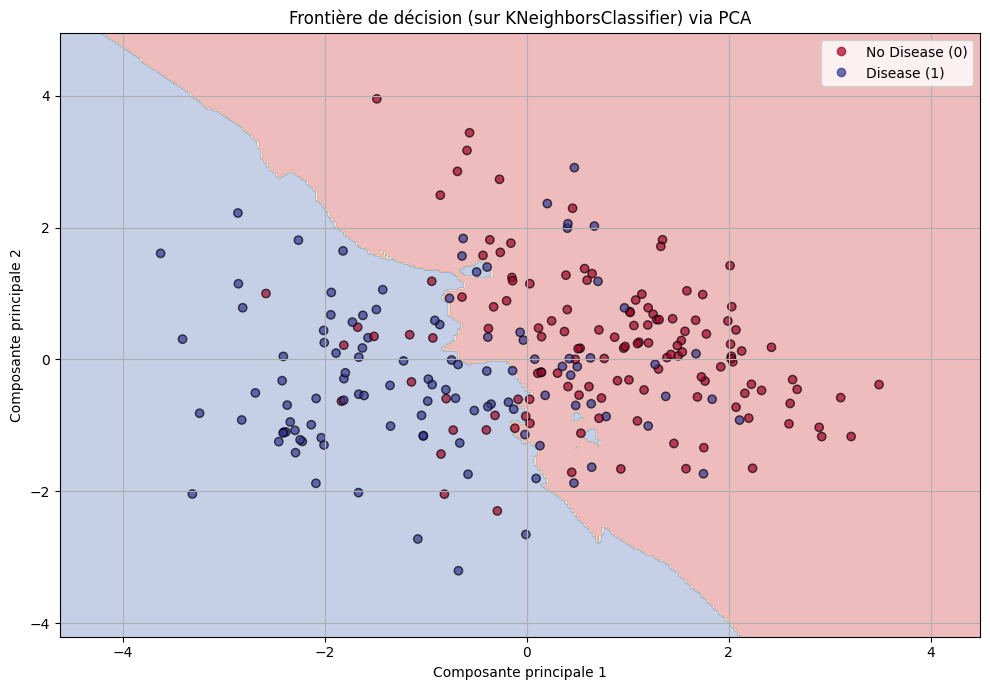

In [24]:
# Cellule 8: GRAPHIQUE 4 - Frontière de Décision (PCA)
PlotFrontiereDecision(results, X_train, y_train)